# Differential Expression Analysis and Enrichments
# DDEA Course June 2026

**How to use this notebook:**
1. ⚠️ Go to **Runtime → Change runtime type → R** before running anything
2. Run the **Install packages** cell first — takes several minutes, run once
3. Upload the data files as instructed
4. Work through each exercise sequentially
5. For each 💡 exercise, write your code in the provided cell. The answer is in the collapsed cell directly below — click the **▶ Answer** button to expand it.

In [2]:
# Install required packages — run this cell once before anything else.
# This will take several minutes on first run.

install.packages(c("tidyverse", "plotly", "sessioninfo"), quiet = TRUE)

if (!requireNamespace("BiocManager", quietly = TRUE))
    install.packages("BiocManager")

BiocManager::install(c(
    "limma",
    "EnhancedVolcano",
    "clusterProfiler",
    "org.Mm.eg.db",
    "enrichplot",
    "ggridges"
), ask = FALSE, update = FALSE)

also installing the dependencies ‘lazyeval’, ‘crosstalk’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)

Installing package(s) 'BiocVersion', 'limma', 'EnhancedVolcano',
  'clusterProfiler', 'org.Mm.eg.db', 'enrichplot'

also installing the dependencies ‘fontBitstreamVera’, ‘fontLiberation’, ‘XVector’, ‘Seqinfo’, ‘fontquiver’, ‘png’, ‘Biostrings’, ‘gridGraphics’, ‘gdtools’, ‘tweenr’, ‘polyclip’, ‘BiocGenerics’, ‘Biobase’, ‘IRanges’, ‘RSQLite’, ‘S4Vectors’, ‘KEGGREST’, ‘ggplotify’, ‘patchwork’, ‘ape’, ‘ggiraph’, ‘tidytree’, ‘treeio’, ‘ggforce’, ‘statmod’, ‘ggrepel’, ‘aisdk’, ‘AnnotationDbi’, ‘enrichit’, ‘GO.db’, ‘GOSemSim’, ‘gson’, ‘igraph’, ‘plyr’, ‘qvalue’, ‘yulab.utils’, ‘aplot’, ‘DOSE’, 

In [17]:
knitr::opts_chunk$set(warning = FALSE, message = FALSE)
options(warn = -1)
library(tidyverse)
library(plotly)
library(limma)
library(EnhancedVolcano)
library(clusterProfiler)
library(org.Mm.eg.db)
library(enrichplot)
library(ggridges)


ERROR: Error in library(ggridges): there is no package called ‘ggridges’


## Upload the data

The dataset is a liver proteome from WT (lean) and ob/ob mice (n = 4 per group), from (https://www.sciencedirect.com/science/article/pii/S1535947622000159). The data we will use has already been log2-transformed, filtered, imputed, and normalised. `metadata.tsv` contains sample names and group assignments.



In [7]:
# Clone course data (always needed — data lives on GitHub, not Drive)
if (!dir.exists('DDEA_proteomics_course'))
  system('git clone --depth 1 https://github.com/fpm-cbmr/DDEA_proteomics_course.git')
setwd('DDEA_proteomics_course')

data     <- read.delim("data/data_norm.tsv")
metadata <- read.delim("data/metadata.tsv")


data     <- read.delim(file.path(repo_dir, "data/data_norm.tsv"))
metadata <- read.delim(file.path(repo_dir, "data/metadata.tsv"))

---

## 1. Check data prerequisites for limma

Limma assumes that data is already **log2-transformed** and **normalised**, that distributions are comparable across samples, and that there are no (or very few) missing values.

💡 **Exercise 1: Check the data**

Inspect the dataset to verify it meets limma's requirements:
- Check data normality and compare sample distributions (boxplot and density plot)
- Check for balanced design and missing values

In [ ]:
# Your code here

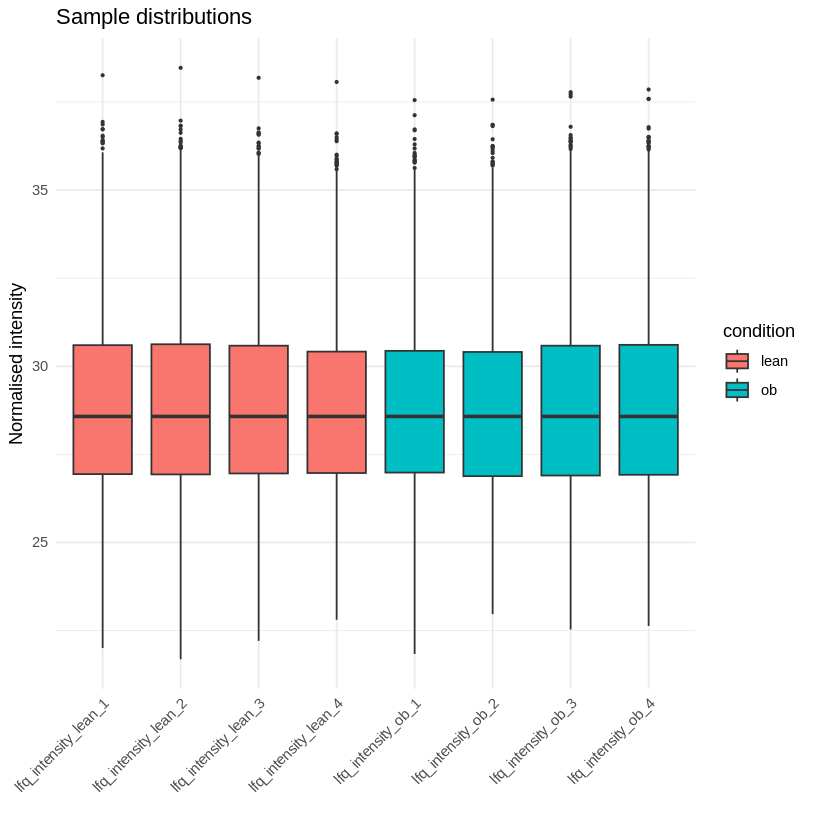

Total NAs: 0 
lfq_intensity_lean_1 lfq_intensity_lean_2 lfq_intensity_lean_3 
                   0                    0                    0 
lfq_intensity_lean_4   lfq_intensity_ob_1   lfq_intensity_ob_2 
                   0                    0                    0 
  lfq_intensity_ob_3   lfq_intensity_ob_4 
                   0                    0 

lean   ob 
   4    4 


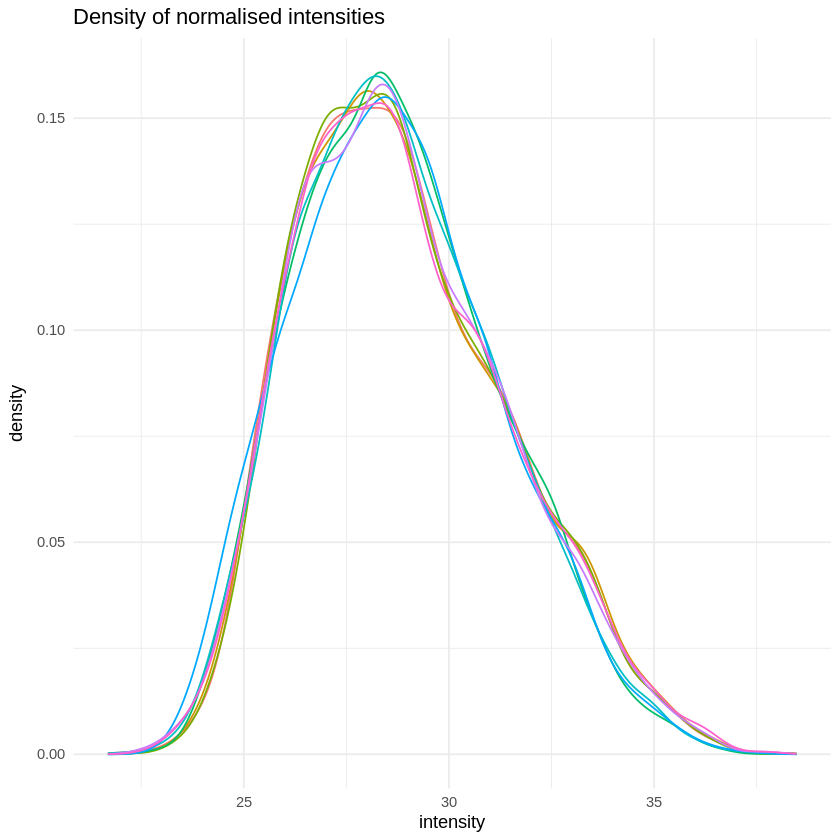

In [8]:
#@title 🔑 Answer — Exercise 1

# Reshape to long format for plotting
data_long <- data |>
    rownames_to_column("protein") |>
    pivot_longer(-protein, names_to = "sample", values_to = "intensity") |>
    left_join(metadata, by = c("sample" = "sample_ID"))

# Boxplot
ggplot(data_long, aes(x = sample, y = intensity, fill = condition)) +
    geom_boxplot(outlier.size = 0.5) +
    theme_minimal() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    labs(title = "Sample distributions", y = "Normalised intensity", x = NULL)

# Density plot
ggplot(data_long, aes(x = intensity, colour = sample)) +
    geom_density() +
    theme_minimal() +
    theme(legend.position = "none") +
    labs(title = "Density of normalised intensities")

# Missing values
cat("Total NAs:", sum(is.na(data)), "\n")
print(colSums(is.na(data)))

# Samples per group
print(table(metadata$condition))

---

## 2. Differential expression analysis with limma

We have two groups: **lean** mice and **ob** mice. Start by encoding group membership as a factor:

In [9]:
group <- factor(metadata$condition, levels = c("lean", "ob"))

💡 **Exercise 2: Fit the limma model (Approach 1 — no-intercept design)**

Use the `~0 +` design so each column of the design matrix represents a group mean directly. Then define an explicit contrast for ob vs lean.

1. Build a design matrix with `model.matrix(~0 + group)` and rename columns
2. Fit the model with `lmFit()`
3. Define the contrast `ob - lean` with `makeContrasts()`
4. Apply the contrast with `contrasts.fit()`, then `eBayes()`
5. Extract results with `topTable()` (all proteins, BH correction)
6. Add a `Gene` column from `rownames()`

Store your final results in `results_approach1`.

In [ ]:
# your code

In [10]:
#@title 🔑 Answer — Exercise 2

# Step 1: design matrix
design <- model.matrix(~0 + group)
colnames(design) <- c("lean", "ob")

# Step 2: fit model
fit_1 <- lmFit(object = data, design = design)

# Step 3: contrast matrix
contrast_matrix <- makeContrasts(ob - lean, levels = design)

# Step 4: apply contrast + empirical Bayes
fit_2 <- contrasts.fit(fit_1, contrast_matrix)
fit_2 <- eBayes(fit_2)

# Step 5-6: extract results and add Gene column
results_approach1 <- topTable(
    fit_2,
    coef          = "ob - lean",
    number        = Inf,
    adjust.method = "BH"
)
results_approach1$Gene <- rownames(results_approach1)

head(results_approach1)

,logFC,AveExpr,t,P.Value,adj.P.Val,B,Gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Sprr1a,9.231877,27.02903,18.59526,2.367357e-08,0.0001141776,9.310760,Sprr1a
Cbr3,4.381165,28.61801,16.21081,7.651640e-08,0.0001845193,8.416819,Cbr3
Nqo1,3.673270,27.71188,14.00965,2.636579e-07,0.0004238740,7.398431,Nqo1
Gstm3,2.480537,32.20240,12.94136,5.136064e-07,0.0006192809,6.820885,Gstm3
Hsd3b5,-4.796751,30.48242,-12.47514,6.980823e-07,0.0006733702,6.548978,Hsd3b5
Abcd2,5.490261,27.54973,11.56501,1.310844e-06,0.0009298119,5.979558,Abcd2


### Reference: Approach 2 — intercept design

There is a simpler alternative for 2-group comparisons that skips `makeContrasts()`. Both approaches give mathematically identical results. Approach 1 becomes necessary when you have 3+ groups and want to define all pairwise contrasts.

Expand the cell below to see the code & try to understand the differences

In [11]:
#@title 📖 Reference — Approach 2 code

design <- model.matrix(~ group)   # column "groupob" = ob - lean
fit_1  <- lmFit(object = data, design = design)
fit_2  <- eBayes(fit_1)

results_approach2 <- topTable(fit_2,
                               coef          = "groupob",
                               number        = Inf,
                               adjust.method = "BH")

results_approach2$Gene <- rownames(results_approach2)

head(results_approach2)

,logFC,AveExpr,t,P.Value,adj.P.Val,B,Gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Sprr1a,9.231877,27.02903,18.59526,2.367357e-08,0.0001141776,9.310760,Sprr1a
Cbr3,4.381165,28.61801,16.21081,7.651640e-08,0.0001845193,8.416819,Cbr3
Nqo1,3.673270,27.71188,14.00965,2.636579e-07,0.0004238740,7.398431,Nqo1
Gstm3,2.480537,32.20240,12.94136,5.136064e-07,0.0006192809,6.820885,Gstm3
Hsd3b5,-4.796751,30.48242,-12.47514,6.980823e-07,0.0006733702,6.548978,Hsd3b5
Abcd2,5.490261,27.54973,11.56501,1.310844e-06,0.0009298119,5.979558,Abcd2


---

💡 **Exercise 3: P-value distribution**

Plot a histogram of the raw p-values from `results_approach1`.

What does the shape tell you about whether the model is well-specified? *(Hint: think about what you expect under the null and under true signal.)*

In [ ]:
# Your code here

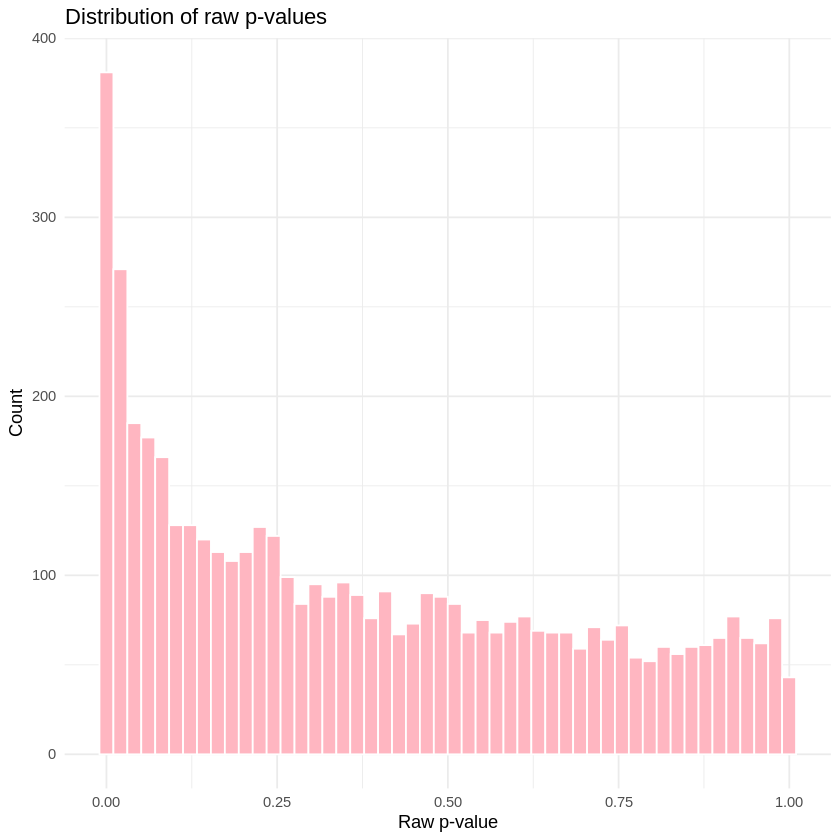

In [12]:
#@title 🔑 Answer — Exercise 3

ggplot(results_approach1, aes(x = P.Value)) +
    geom_histogram(bins = 50, fill = "lightpink", colour = "white") +
    theme_minimal() +
    labs(
        title = "Distribution of raw p-values",
        x     = "Raw p-value",
        y     = "Count"
    )

# A well-specified model shows a spike near 0 (true signal) on a flat uniform background. A spike near 1 or a U-shape would suggest model misspecification.

---

## 3. Visualise limma results

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the EnhancedVolcano package.
  Please report the issue to the authors.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the EnhancedVolcano package.
  Please report the issue to the authors.”


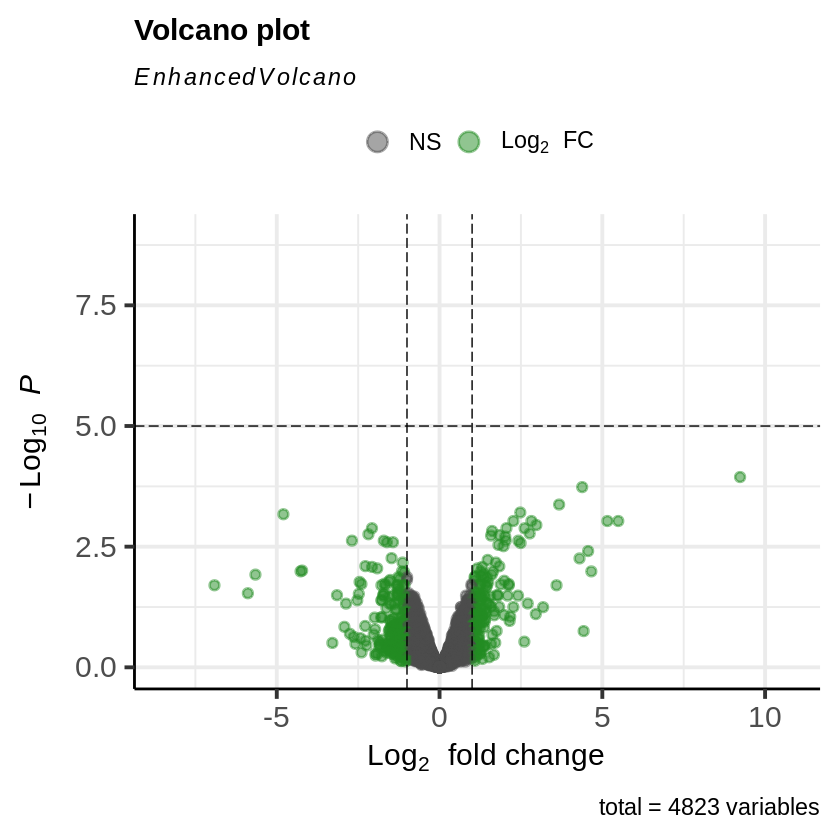

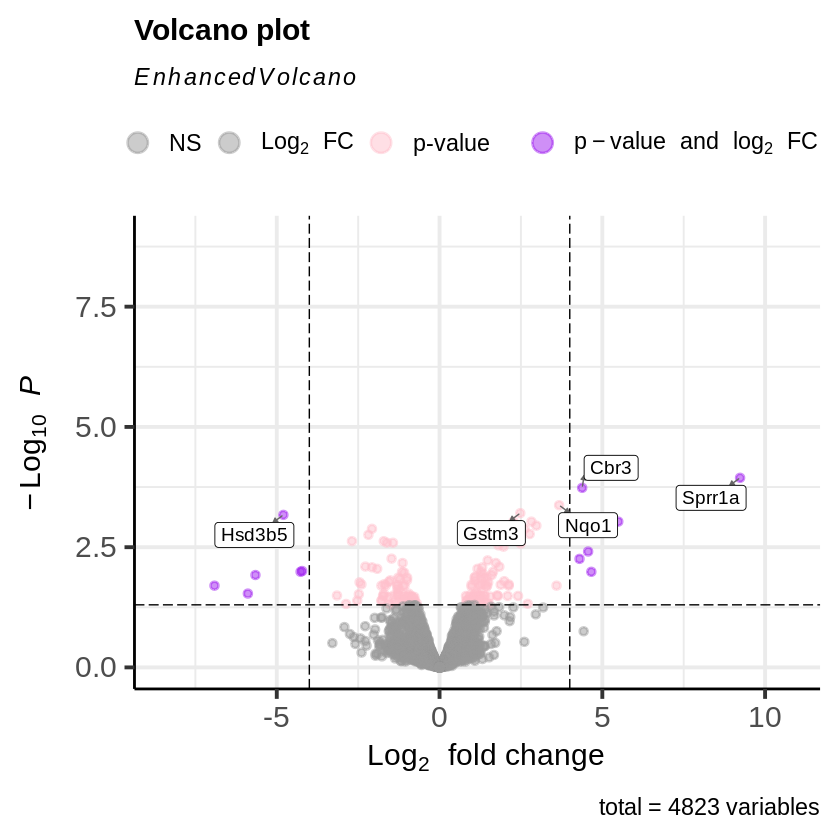

In [13]:
EnhancedVolcano(results_approach1,
                lab = rownames(results_approach1),
                x   = "logFC",
                y   = "adj.P.Val")

# There are many different options you can add:

# label top hits
top_genes <- rownames(results_approach1[order(results_approach1$adj.P.Val), ])[1:5]

EnhancedVolcano(results_approach1,
                lab = rownames(results_approach1),
                x   = "logFC",
                y   = "adj.P.Val",

                # custom thresholds
                pCutoff = 0.05,
                FCcutoff = 4,

                selectLab = top_genes,

                # custom colors
                colCustom = NULL,
                col = c("grey60",      # NS
                        "grey60",      # FC only (same as NS, we don't want this colored)
                        "pink",        # p sig only
                        "purple"),     # p sig + FC

                drawConnectors = TRUE,
                widthConnectors = 0.4,
                colConnectors = "grey40",
                boxedLabels = TRUE,
                labSize = 4,
                pointSize = 1.5)

💡 **Exercise 4: Discussion — interpreting the volcano plot**

Discuss with your neighbour:
- What does the x-axis represent? What does a positive value mean biologically?
- What does the y-axis represent? Why do we use -log10 of the adjusted p-value?



---

## 4. Gene Set Enrichment Analysis (GSEA)

GSEA uses the full ranked list of proteins (by logFC) — no significance threshold needed.

In [14]:
ranked_list <- results_approach1 |>
    arrange(desc(logFC)) |>
    (\(df) setNames(df$logFC, df$Gene))()

gsea <- clusterProfiler::gseGO(
    geneList      = ranked_list,
    ont           = "ALL",          # "CC", "BP", or "MF" for individual ontologies
    keyType       = "SYMBOL",
    minGSSize     = 10,
    maxGSSize     = 500,
    pvalueCutoff  = 0.05,
    verbose       = TRUE,
    OrgDb         = org.Mm.eg.db,
    pAdjustMethod = "BH"
)

Warning message in gsea(geneList = geneList, gene_sets = geneSets, minGSSize = minGSSize, :
“There were 270 pathways for which P-values were not calculated properly due to unbalanced gene-level statistic values. For such pathways pvalue, NES and log2err are set to NA. You can try to increase nPermSimple.”
Warning message in calculate_qvalue(gsea_res$pvalue):
“Invalid p-values detected (NA, non-finite, <0, or >1). qvalue will be computed on valid p-values only.”
Warning message in enrichit::gsea_gson(geneList = geneList, exponent = exponent, :
“NA values detected in gene set IDs. Replacing with string 'NA'.”
Warning message in enrichit::gsea_gson(geneList = geneList, exponent = exponent, :
“Duplicate gene set IDs detected: NA... (Total 1). Unique suffixes added.”


💡 **Exercise 5: Visualise GSEA results**

The cell below shows several plot types. Run it and discuss with your neighbour:
- What does each plot represent?
- What is the default dotplot showing on the x-axis?
- In the second dotplot we specify `x = "NES"` why and what is NES?
- Are the activated and suppressed pathways biologically coherent?

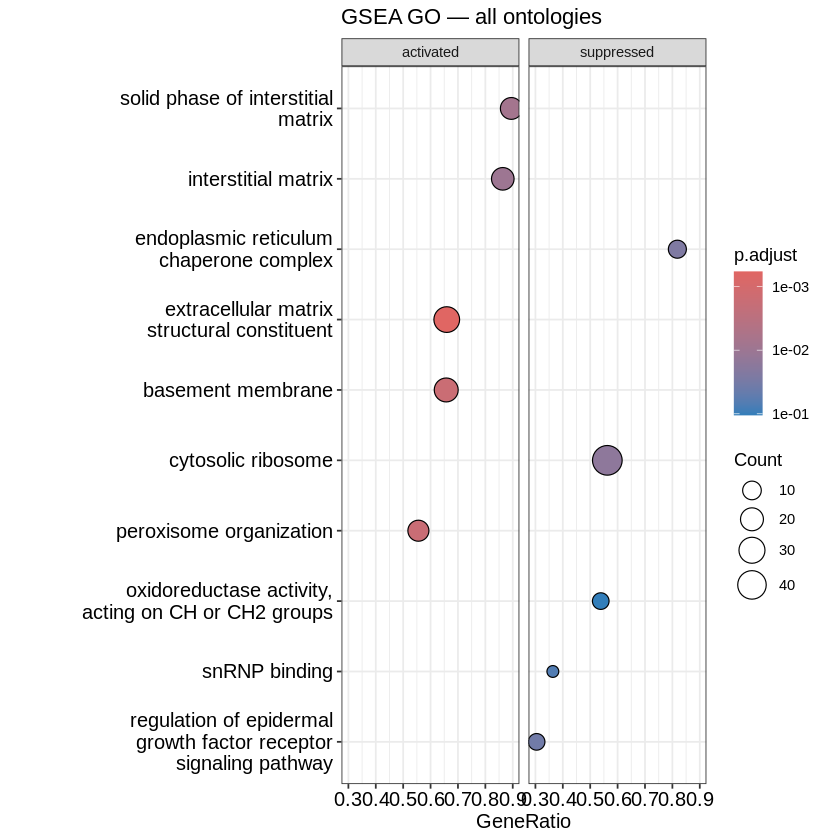

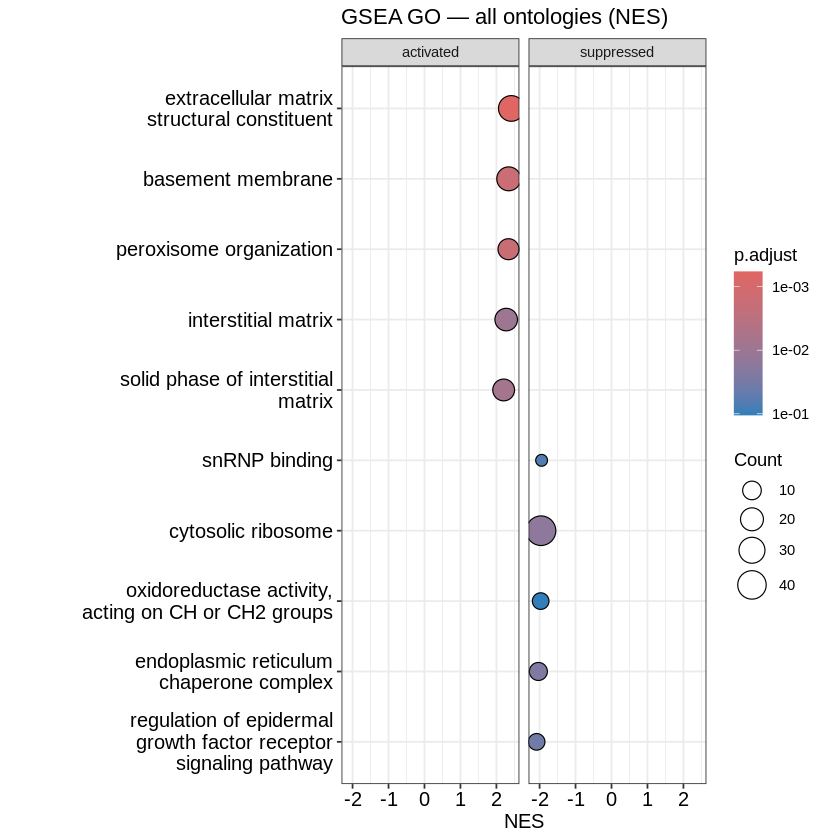

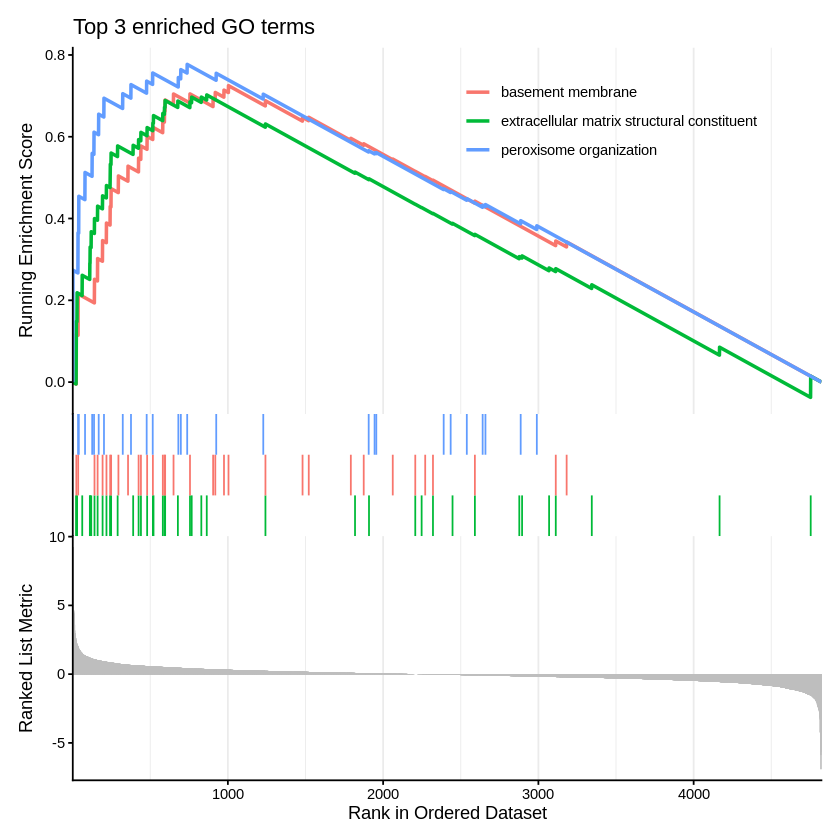

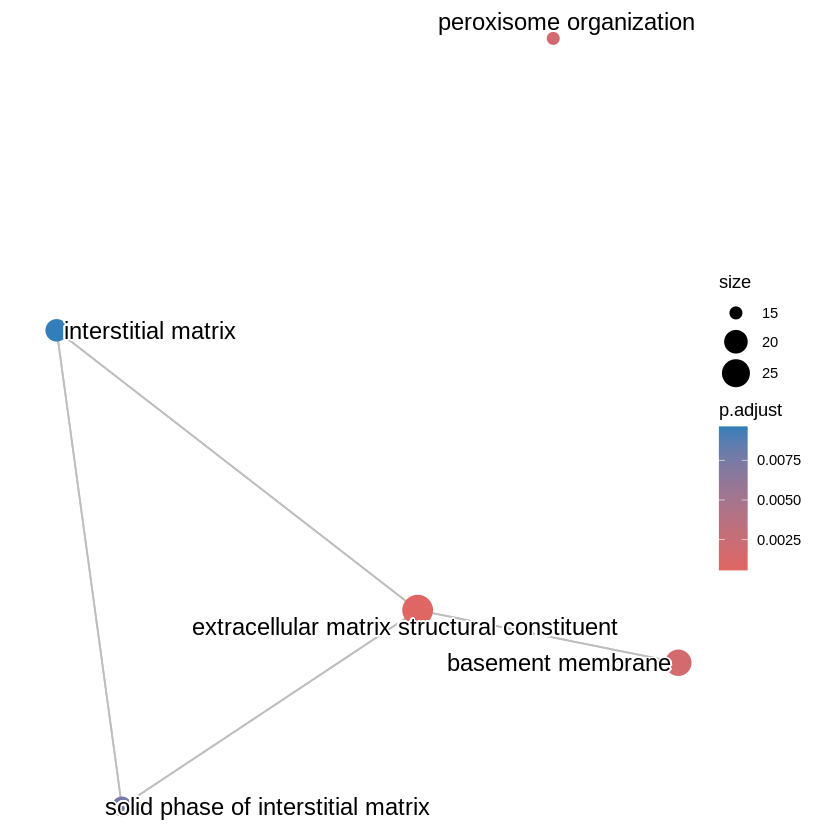

ERROR: [1m[33mError[39m in `ridgeplot.gseaResult()`:[22m
[1m[22m[33m![39m The package "ggridges" is required for `ridgeplot()`.


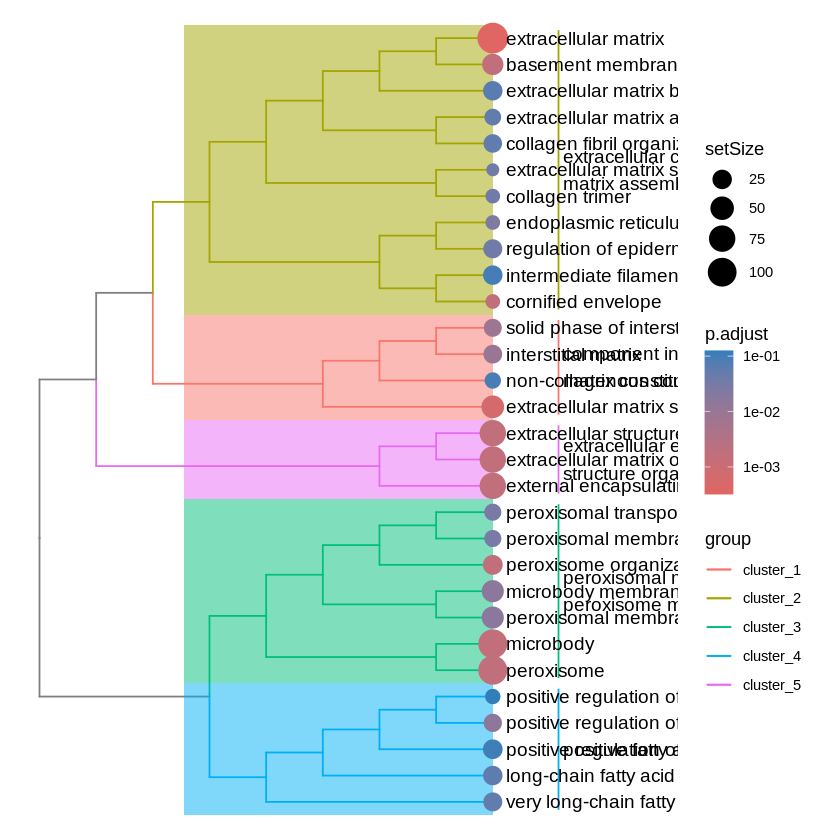

In [16]:
# Dotplot — default x axis
dotplot(gsea, showCategory = 5, split = ".sign") +
    facet_grid(. ~ .sign) +
    ggtitle("GSEA GO — all ontologies")

# Dotplot — x axis = NES (Normalised Enrichment Score)
dotplot(gsea, x = "NES", showCategory = 5, split = ".sign") +
    facet_grid(. ~ .sign) +
    ggtitle("GSEA GO — all ontologies (NES)")

# GSEA enrichment curves for top terms
gseaplot2(gsea, geneSetID = 1:5, title = "Top 5 enriched GO terms")

# Similarity-based network and tree (require pairwise_termsim first)
gsea_sim <- enrichplot::pairwise_termsim(gsea)
emapplot(gsea_sim, showCategory = 10)
treeplot(gsea_sim)

# Ridge plot of logFC distributions per term
ridgeplot(gsea, showCategory = 5)

---

## 5. Dealing with redundant GO terms

Many GO terms are semantically similar and will appear together. Run a single ontology to make this easier to see:

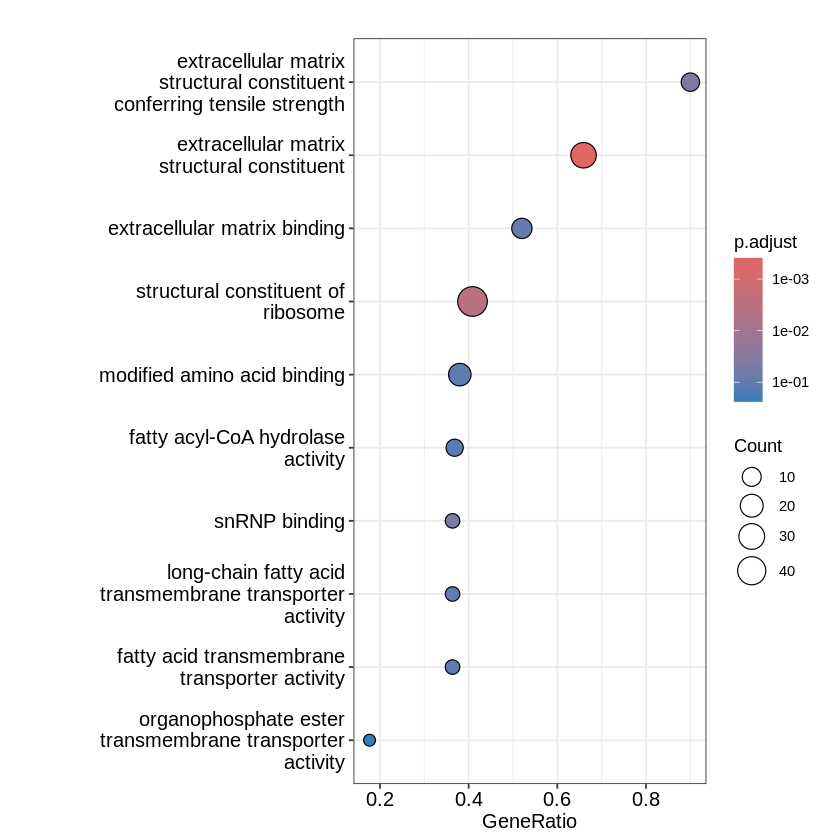

In [18]:
gsea_MF <- clusterProfiler::gseGO(
    geneList      = ranked_list,
    ont           = "MF",
    keyType       = "SYMBOL",
    minGSSize     = 10,
    maxGSSize     = 500,
    pvalueCutoff  = 0.05,
    verbose       = TRUE,
    OrgDb         = org.Mm.eg.db,
    pAdjustMethod = "BH"
)

dotplot(gsea_MF)

💡 **Exercise 6: Simplify redundant terms**

Do you see redundant GO terms in the dotplot above?

Use `clusterProfiler::simplify()` to reduce redundancy. Try adjusting the `cutoff` parameter (default 0.7 — lower values are more aggressive). Compare the dotplots before and after.

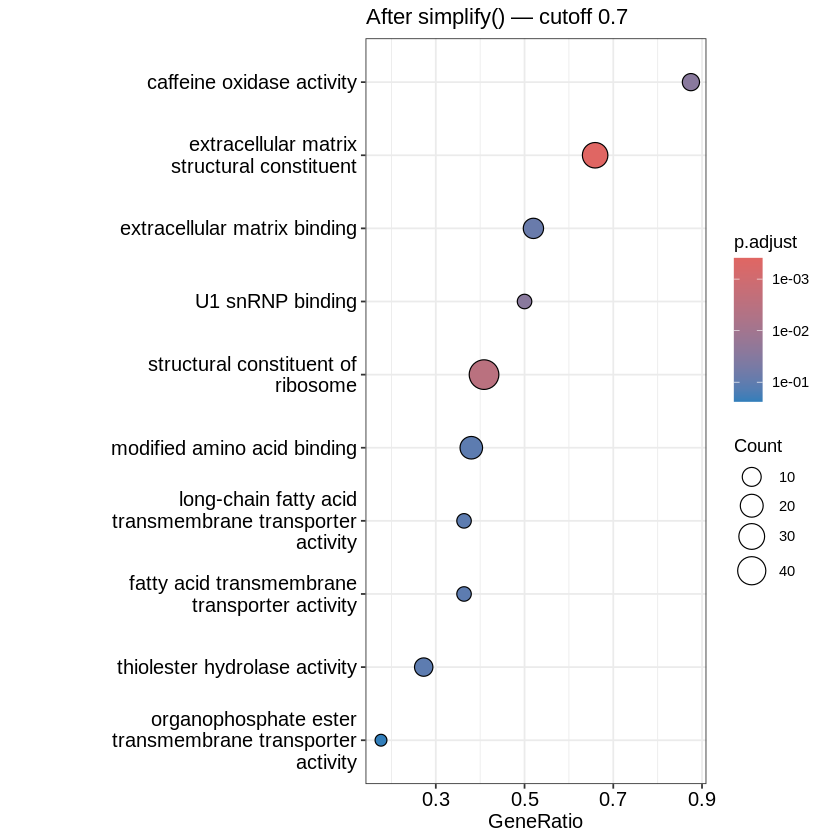

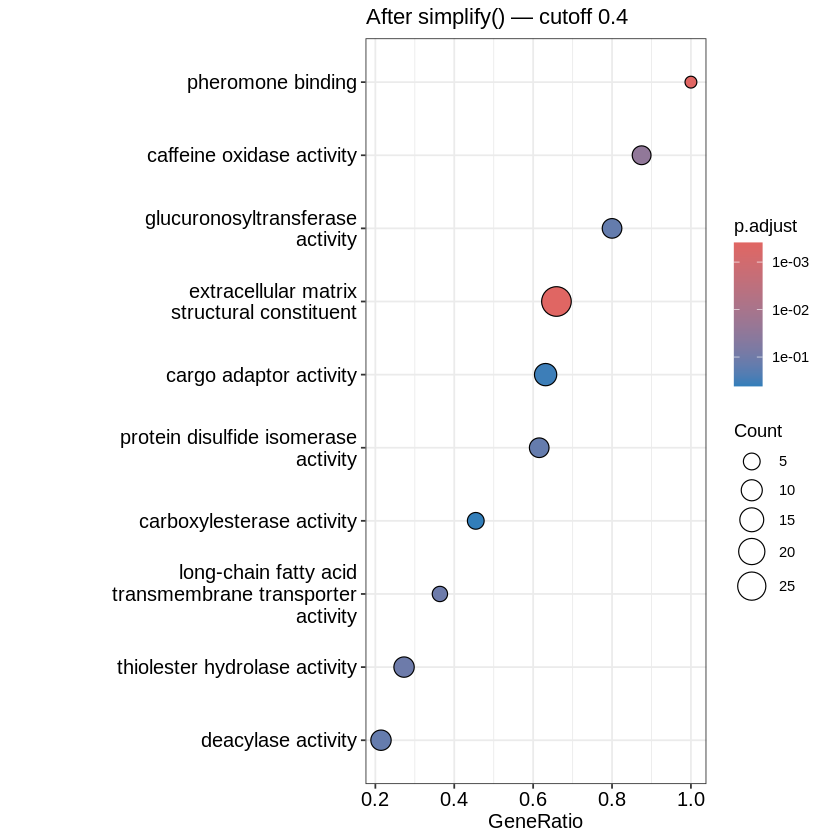

In [22]:
#@title 🔑 Answer — Exercise 6

gsea_MF_simplified <- clusterProfiler::simplify(gsea_MF, cutoff = 0.7) # 0.7 is default

dotplot(gsea_MF_simplified) +
    ggtitle("After simplify() — cutoff 0.7")

# Try a more aggressive cutoff
gsea_MF_strict <- clusterProfiler::simplify(gsea_MF, cutoff = 0.3)
dotplot(gsea_MF_strict) +
    ggtitle("After simplify() — cutoff 0.4")

---

## 6. KEGG pathway enrichment

KEGG requires Entrez IDs rather than gene symbols.

'select()' returned 1:1 mapping between keys and columns

Reading KEGG annotation online: "https://rest.kegg.jp/link/mmu/pathway"...

Reading KEGG annotation online: "https://rest.kegg.jp/list/pathway/mmu"...



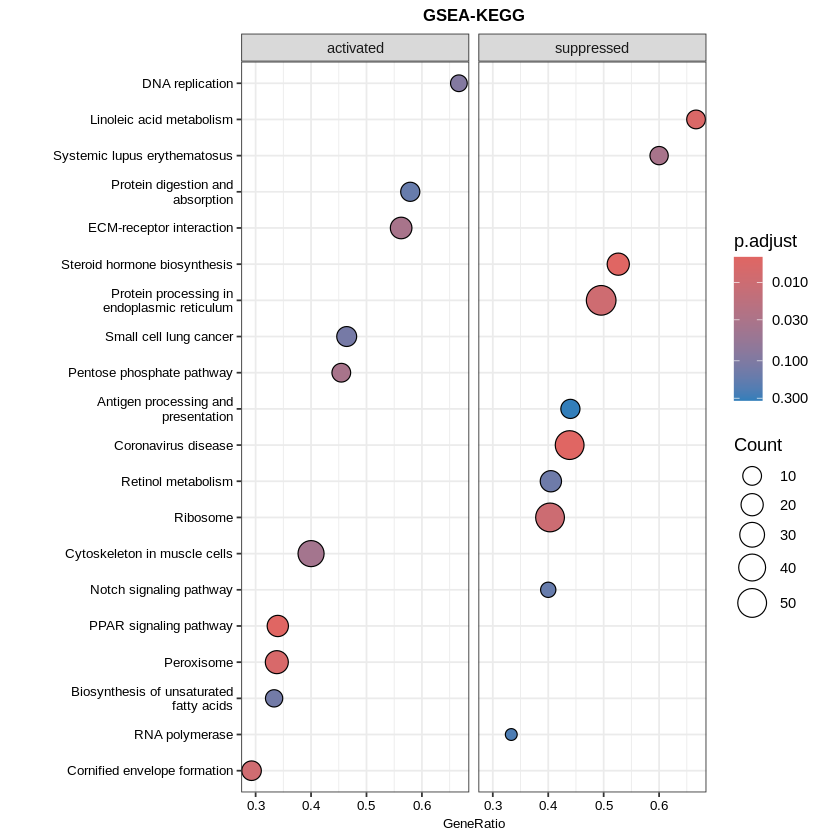

In [23]:
gene_entrez <- clusterProfiler::bitr(
    results_approach1$Gene,
    fromType = "SYMBOL",
    toType   = "ENTREZID",
    OrgDb    = org.Mm.eg.db
)

ranked_kegg <- results_approach1 |>
    left_join(gene_entrez, by = c("Gene" = "SYMBOL")) |>
    filter(!is.na(ENTREZID)) |>
    arrange(desc(logFC)) |>
    distinct(ENTREZID, .keep_all = TRUE) |>   # keep one entry per Entrez ID (highest logFC wins)
    (\(df) setNames(df$logFC, df$ENTREZID))()

gsea_kegg <- clusterProfiler::gseKEGG(
    geneList      = ranked_kegg,
    organism      = "mmu",       # mmu = Mus musculus; "hsa" for human
    minGSSize     = 10,
    maxGSSize     = 500,
    pvalueCutoff  = 0.05,
    pAdjustMethod = "BH",
    verbose       = TRUE
)

dotplot(gsea_kegg, showCategory = 10, split = ".sign", font.size = 8) +
    facet_grid(. ~ .sign) +
    ggtitle("GSEA-KEGG") +
    theme(plot.title = element_text(size = 10, face = "bold", hjust = 0.5))

---

## 7. Over-Representation Analysis (ORA)

ORA tests whether a predefined gene set is over-represented among your **significant** proteins compared to a background. Unlike GSEA, it requires a significance threshold.

In [24]:
sig        <- results_approach1 |> filter(adj.P.Val < 0.05) |> pull(Gene)
background <- results_approach1 |> pull(Gene)

ora <- clusterProfiler::enrichGO(
    gene          = sig,
    universe      = background,
    OrgDb         = org.Mm.eg.db,
    keyType       = "SYMBOL",
    ont           = "ALL",
    minGSSize     = 10,
    maxGSSize     = 500,
    pAdjustMethod = "BH",
    pvalueCutoff  = 0.05,
    qvalueCutoff  = 0.05
)

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns



💡 **Exercise 7: Visualise ORA and compare to GSEA**

1. Create a dotplot of the ORA results
2. Run ORA separately for upregulated and downregulated proteins
3. Discuss with your neighbour:
   - What is the key conceptual difference between ORA and GSEA?
   - Do the two methods agree on the enriched pathways?
   - What are the pros and cons of each?

In [ ]:
# Your code here

# Hint: filter results_approach1 for adj.P.Val < 0.05 and logFC > 0 (up) or < 0 (down),
# then run enrichGO separately for each direction

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns



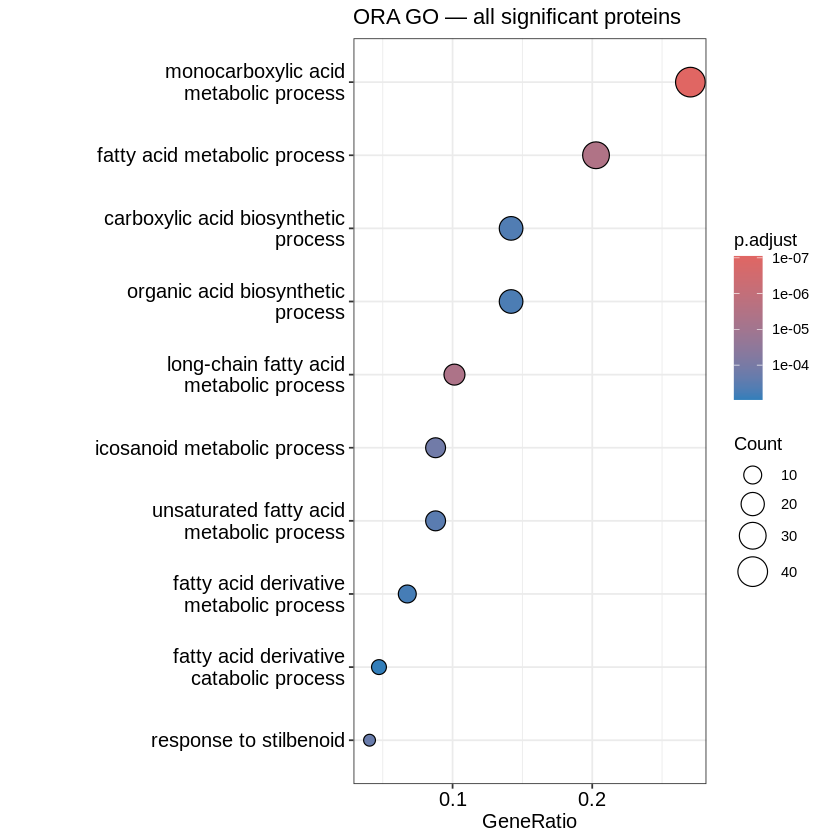

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns



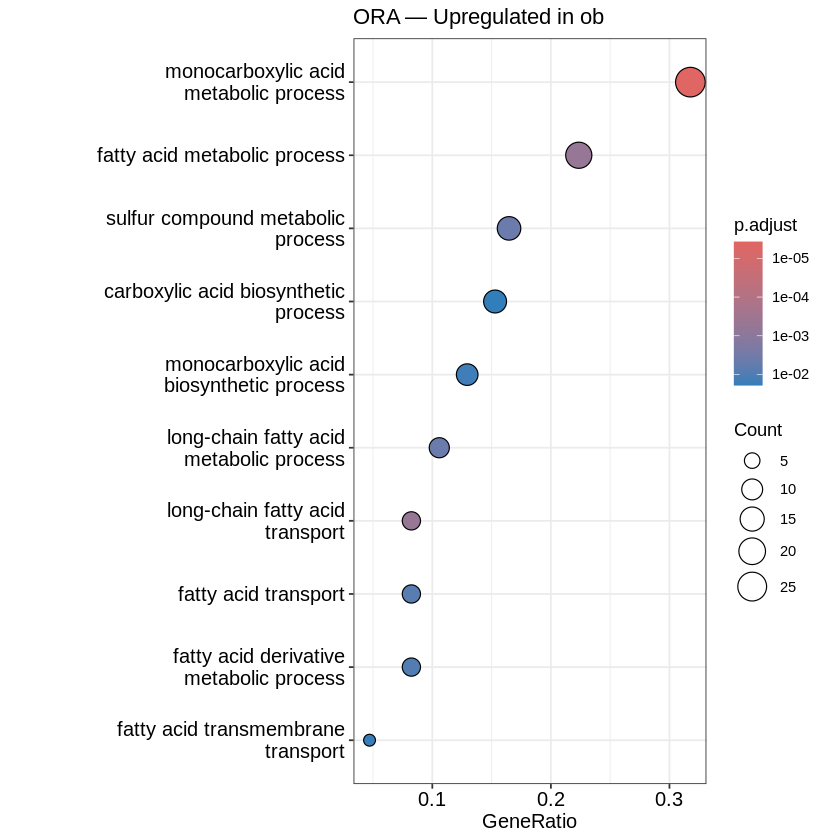

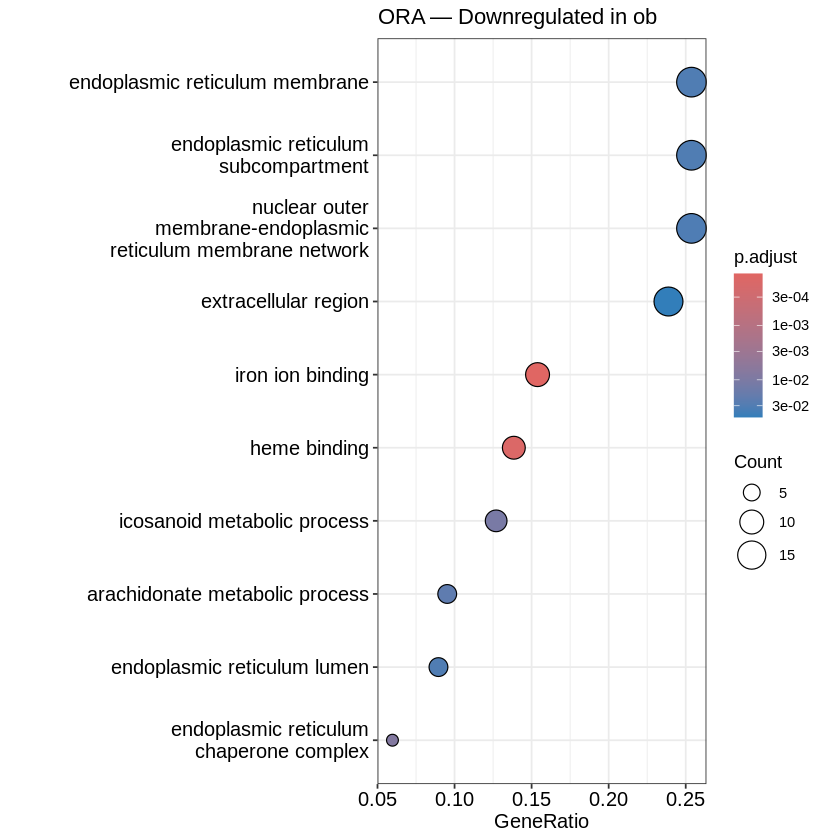

In [25]:
#@title 🔑 Answer — Exercise 7

# Dotplot of combined ORA
dotplot(ora, showCategory = 10) +
    ggtitle("ORA GO — all significant proteins")

# Upregulated proteins only
up_genes <- results_approach1 |>
    filter(adj.P.Val < 0.05, logFC > 0) |>
    pull(Gene)

ora_up <- clusterProfiler::enrichGO(
    gene          = up_genes,
    universe      = background,
    OrgDb         = org.Mm.eg.db,
    keyType       = "SYMBOL",
    ont           = "ALL",
    pAdjustMethod = "BH",
    pvalueCutoff  = 0.05,
    qvalueCutoff  = 0.05
)
dotplot(ora_up, showCategory = 10) + ggtitle("ORA — Upregulated in ob")

# Downregulated proteins only
down_genes <- results_approach1 |>
    filter(adj.P.Val < 0.05, logFC < 0) |>
    pull(Gene)

ora_down <- clusterProfiler::enrichGO(
    gene          = down_genes,
    universe      = background,
    OrgDb         = org.Mm.eg.db,
    keyType       = "SYMBOL",
    ont           = "ALL",
    pAdjustMethod = "BH",
    pvalueCutoff  = 0.05,
    qvalueCutoff  = 0.05
)
dotplot(ora_down, showCategory = 10) + ggtitle("ORA — Downregulated in ob")

---

## 8. KEGG ORA

kegg_category.rda is not found, download it online...



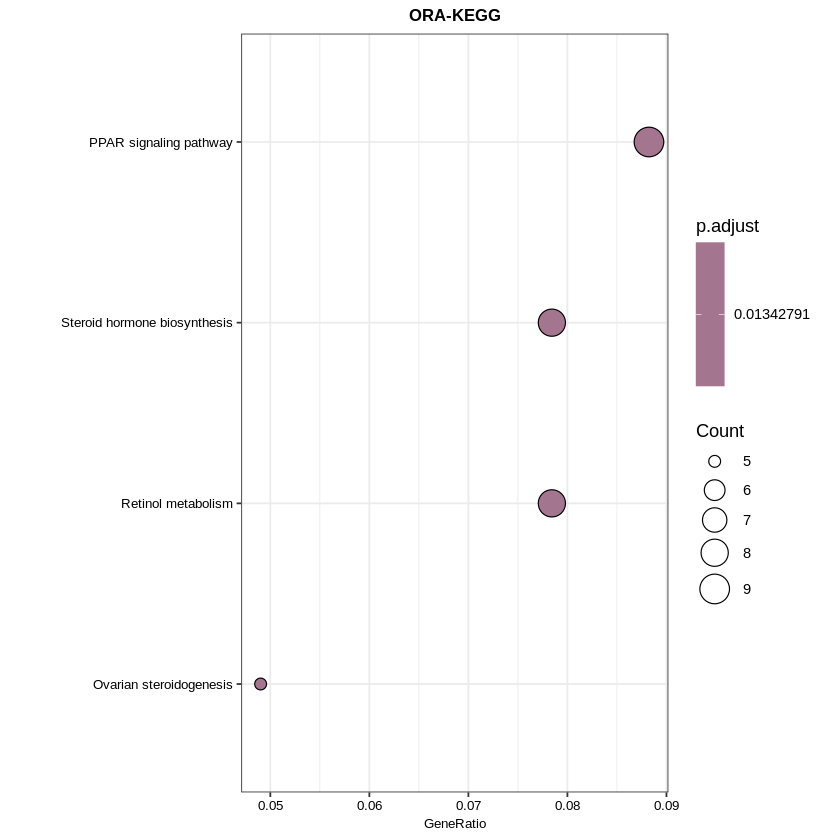

In [26]:
sig_entrez        <- gene_entrez |> filter(SYMBOL %in% sig) |> pull(ENTREZID) |> unique()
background_entrez <- gene_entrez$ENTREZID |> unique()

ora_kegg <- clusterProfiler::enrichKEGG(
    gene          = sig_entrez,
    universe      = background_entrez,
    organism      = "mmu",
    minGSSize     = 10,
    maxGSSize     = 500,
    pAdjustMethod = "BH",
    pvalueCutoff  = 0.05,
    qvalueCutoff  = 0.05
)

dotplot(ora_kegg, showCategory = 10, font.size = 8) +
    ggtitle("ORA-KEGG") +
    theme(plot.title = element_text(size = 10, face = "bold", hjust = 0.5))

---

## Extra Exercises

*If you have time, go through the [limma user guide](https://bioconductor.org/packages/release/bioc/vignettes/limma/inst/doc/usersguide.pdf) and look into how to write code for more complex designs.*

---

💡 **Exercise 8: Discussion — 3-group design**

Imagine you had three groups: **lean**, **ob**, and **diabetic**. How would you perform the limma DEA? Discuss with your neighbour.

*(Hint: which of the two approaches from Exercise 2 would you use, and how would you define the contrasts?)*

---

💡 **Exercise 9: Discussion — paired design**

Imagine you had two groups (**treated** and **control**) with one measurement per subject before and after intervention — a paired design. How can you run limma in a paired design? Discuss with your neighbour.

*(Hint: look into the `duplicateCorrelation()` function and blocking factors in limma.)*

In [ ]:
sessioninfo::session_info()